In [ ]:
from __future__ import annotations

import os
import shutil
import subprocess
import sys
from pathlib import Path

# Notebook ini bisa dijalankan di Colab ATAU lokal repo.
# - Colab: akan auto-clone repo (kalau belum ada) lalu cd ke machine-learning/
# - Lokal: akan coba auto-locate folder machine-learning/ dari cwd
BRANCH = "ML-ghildan"
REPO_URL = "https://github.com/ghildnsy/Heartz.git"

# Set True kalau kernel masih kosong (contoh: Colab fresh).
INSTALL_DEPS = False

def is_colab() -> bool:
    return "google.colab" in sys.modules or Path("/content").exists()

if is_colab():
    repo_root = Path("/content/Heartz")
    if not repo_root.exists():
        subprocess.run(
            ["git", "clone", "-b", BRANCH, "--single-branch", REPO_URL, str(repo_root)],
            check=True,
        )
    os.chdir(repo_root / "machine-learning")
else:
    cwd = Path.cwd()
    candidates = [cwd, cwd.parent, cwd.parent.parent]
    ml_root: Path | None = None
    for c in candidates:
        # case 1: already inside machine-learning/
        if (c / "outputs").exists() and (c / "api").exists() and (c / "requirements.txt").exists():
            ml_root = c
            break
        # case 2: inside repo root
        if (c / "machine-learning").exists() and (c / "machine-learning" / "outputs").exists():
            ml_root = c / "machine-learning"
            break
    if ml_root is not None:
        os.chdir(ml_root)
    else:
        print("[WARN] Could not auto-locate `machine-learning/` root. Current:", cwd)

print("Working directory:", Path.cwd())
print("Has data/clean_wav:", (Path("data") / "clean_wav").exists())
print("Has outputs/:", Path("outputs").exists())

if INSTALL_DEPS:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])

Cloning into 'Heartz'...
remote: Enumerating objects: 34548, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 34548 (delta 4), reused 5 (delta 1), pack-reused 34533 (from 2)
Receiving objects: 100% (34548/34548), 896.19 MiB | 30.82 MiB/s, done.
Resolving deltas: 100% (1841/1841), done.
Updating files: 100% (58948/58948), done.
/content/Heartz/machine-learning
/content/Heartz/machine-learning
api  data  notebooks  outputs  README.md  requirements.txt  testing


In [ ]:
from pathlib import Path

# Quick check: dataset summary (per class)
DATA_DIR = Path("data/clean_wav")
if not DATA_DIR.exists():
    print("[WARN] DATA_DIR not found:", DATA_DIR.resolve())
else:
    class_dirs = sorted([p for p in DATA_DIR.iterdir() if p.is_dir()])
    print("Found classes:", len(class_dirs))
    for d in class_dirs:
        n = len(list(d.glob("*.wav")))
        print(f"- {d.name}: {n} wav")

In [ ]:
from pathlib import Path

# Quick check: important output locations
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)
print("outputs/:", OUT_DIR.resolve())
print("Existing files:")
for p in sorted(OUT_DIR.glob("*")):
    print("-", p.name)

/content/Heartz/machine-learning
api  data  notebooks  outputs  README.md  requirements.txt  testing
clean_wav


# Notebook Training Pipeline

Notebook ini sengaja dibuat sebagai versi **simple untuk capstone/reviewer**:

Heartz MVP:

1. TensorFlow/Keras **Functional API**, bukan Sequential.
2. Input model adalah raw waveform 1D: `(16000,)`, 16 kHz, 1 detik.
3. Layer pertama setelah Input adalah custom `MelSpectrogramLayer` berbasis `tf.signal.stft`.
4. CNN 2D from scratch, tanpa pretrained model.
5. Output 20 class softmax.
6. Training pakai custom loop `tf.GradientTape`, bukan `model.fit()`.
7. Loss custom categorical crossentropy + label smoothing `0.1`.
8. Manual early stopping.
9. TensorBoard logging.
10. Export `.keras` dan SavedModel.

## Jobdesk Hub (end-to-end)

Notebook ini sekarang bisa jadi pusat jobdesk ML kamu:

- Load & cek dataset (`data/clean_wav/`)
- Build model (Functional API + custom layer)
- Custom training loop (`tf.GradientTape`) + TensorBoard log
- Evaluasi (Accuracy + MAE) + simpan `outputs/metrics_notebook.json`
- Export model (`.keras` + SavedModel) + metadata

Output penting (yang akan dicek):

```text
outputs/heartz_model.keras
outputs/saved_model/
outputs/class_names.json
outputs/heartz_config.json
outputs/logs/
outputs/metrics_notebook.json
```

## 1. Import library dan setup path

In [4]:
from __future__ import annotations

import json
import math
import os
import random
import shutil
import time
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import tensorflow as tf

print("TensorFlow:", tf.__version__)

# Kalau notebook dijalankan dari folder notebooks/, pindahkan working directory ke root machine-learning/.
cwd = Path.cwd()
if cwd.name == "notebooks":
    os.chdir(cwd.parent)
    print("Changed working directory to:", Path.cwd())
else:
    print("Working directory:", Path.cwd())

TensorFlow: 2.20.0
Working directory: /content/Heartz/machine-learning


## 2. Konfigurasi Heartz

In [5]:
@dataclass(frozen=True)
class HeartzConfig:
    sample_rate: int = 16_000
    duration_seconds: float = 1.0
    num_samples: int = 16_000
    num_classes: int = 20

    frame_length: int = 400       # 25 ms at 16 kHz
    frame_step: int = 160         # 10 ms at 16 kHz
    fft_length: int = 512
    num_mel_bins: int = 64
    lower_edge_hertz: float = 80.0
    upper_edge_hertz: float = 7_600.0

    batch_size: int = 16
    epochs: int = 50
    learning_rate: float = 1e-3
    label_smoothing: float = 0.1
    early_stopping_patience: int = 8
    min_delta: float = 1e-4
    seed: int = 42

CONFIG = HeartzConfig()

CLASS_NAMES = [
    "A", "I", "U", "E", "O",
    "Ba", "Bi", "Bu", "Be", "Bo",
    "Pa", "Pi", "Pu", "Pe", "Po",
    "Ma", "Mi", "Mu", "Me", "Mo",
]
CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASS_NAMES)}

DATA_DIR = Path("data/clean_wav")
OUTPUT_DIR = Path("outputs")
LOG_DIR = OUTPUT_DIR / "logs" / time.strftime("%Y%m%d-%H%M%S")
KERAS_MODEL_PATH = OUTPUT_DIR / "heartz_model.keras"
SAVED_MODEL_DIR = OUTPUT_DIR / "saved_model"
CLASS_NAMES_PATH = OUTPUT_DIR / "class_names.json"
CONFIG_PATH = OUTPUT_DIR / "heartz_config.json"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

random.seed(CONFIG.seed)
np.random.seed(CONFIG.seed)
tf.random.set_seed(CONFIG.seed)

print("Expected data directory:", DATA_DIR.resolve())
print("Classes:", CLASS_NAMES)

Expected data directory: /content/Heartz/machine-learning/data/clean_wav
Classes: ['A', 'I', 'U', 'E', 'O', 'Ba', 'Bi', 'Bu', 'Be', 'Bo', 'Pa', 'Pi', 'Pu', 'Pe', 'Po', 'Ma', 'Mi', 'Mu', 'Me', 'Mo']


## 3. Scan dataset
Audio ideal:

- `.wav`
- sample rate 16 kHz
- durasi 1 detik
- satu file berisi satu pelafalan suku kata

In [6]:
def scan_dataset(data_dir: Path) -> Tuple[List[str], List[int]]:
    paths: List[str] = []
    labels: List[int] = []

    if not data_dir.exists():
        raise FileNotFoundError(
            f"Dataset folder not found: {data_dir.resolve()}\n"
        )

    missing_dirs = [name for name in CLASS_NAMES if not (data_dir / name).exists()]
    if missing_dirs:
        print("WARNING - folder class belum ada:", missing_dirs)

    for class_name in CLASS_NAMES:
        class_dir = data_dir / class_name
        if not class_dir.exists():
            continue
        for wav_path in sorted(class_dir.glob("*.wav")):
            paths.append(str(wav_path))
            labels.append(CLASS_TO_ID[class_name])

    if not paths:
        raise ValueError(
            f"Tidak ada file .wav di {data_dir.resolve()}\n"
            "Isi dataset dulu sebelum training."
        )

    return paths, labels

paths, labels = scan_dataset(DATA_DIR)
print("Total wav files:", len(paths))

# Tampilkan distribusi per class
counts = {name: 0 for name in CLASS_NAMES}
for label_id in labels:
    counts[CLASS_NAMES[label_id]] += 1
counts

Total wav files: 6096


{'A': 345,
 'I': 375,
 'U': 330,
 'E': 240,
 'O': 135,
 'Ba': 156,
 'Bi': 48,
 'Bu': 162,
 'Be': 147,
 'Bo': 156,
 'Pa': 492,
 'Pi': 339,
 'Pu': 369,
 'Pe': 360,
 'Po': 396,
 'Ma': 588,
 'Mi': 603,
 'Mu': 222,
 'Me': 165,
 'Mo': 468}

## 4. Split train/validation/test

In [7]:
def stratified_split(
    paths: List[str],
    labels: List[int],
    train_ratio: float = 0.8,
    val_ratio: float = 0.1,
    seed: int = 42,
):
    rng = random.Random(seed)
    by_class: Dict[int, List[str]] = {i: [] for i in range(CONFIG.num_classes)}

    for path, label in zip(paths, labels):
        by_class[label].append(path)

    train_paths, train_labels = [], []
    val_paths, val_labels = [], []
    test_paths, test_labels = [], []

    for label, class_paths in by_class.items():
        rng.shuffle(class_paths)
        n = len(class_paths)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)

        train_part = class_paths[:n_train]
        val_part = class_paths[n_train:n_train + n_val]
        test_part = class_paths[n_train + n_val:]

        train_paths.extend(train_part)
        train_labels.extend([label] * len(train_part))
        val_paths.extend(val_part)
        val_labels.extend([label] * len(val_part))
        test_paths.extend(test_part)
        test_labels.extend([label] * len(test_part))

    def shuffle_pair(p, y):
        pairs = list(zip(p, y))
        rng.shuffle(pairs)
        if not pairs:
            return [], []
        p2, y2 = zip(*pairs)
        return list(p2), list(y2)

    return (*shuffle_pair(train_paths, train_labels),
            *shuffle_pair(val_paths, val_labels),
            *shuffle_pair(test_paths, test_labels))

train_paths, train_labels, val_paths, val_labels, test_paths, test_labels = stratified_split(
    paths, labels, seed=CONFIG.seed
)

print("Train:", len(train_paths))
print("Val  :", len(val_paths))
print("Test :", len(test_paths))

Train: 4870
Val  : 600
Test : 626


## 5. Loader audio `.wav` sebagai raw waveform

Loader ini memakai `tf.audio.decode_wav` untuk membaca waveform.

In [8]:
def load_wav_tensor(path: tf.Tensor, label: tf.Tensor):
    audio_binary = tf.io.read_file(path)
    audio, sample_rate = tf.audio.decode_wav(
        audio_binary,
        desired_channels=1,
        desired_samples=CONFIG.num_samples,
    )

    # Dataset seharusnya sudah 16 kHz dari tim Data Science.
    # Assertion ini sengaja dibuat supaya salah sample rate cepat ketahuan.
    tf.debugging.assert_equal(
        sample_rate,
        CONFIG.sample_rate,
        message="Sample rate harus 16000 Hz. Resample dataset dulu di pipeline Data Science.",
    )

    waveform = tf.squeeze(audio, axis=-1)  # (16000,)
    waveform = tf.cast(waveform, tf.float32)
    one_hot = tf.one_hot(label, depth=CONFIG.num_classes)
    return waveform, one_hot


def make_dataset(paths: List[str], labels: List[int], training: bool) -> tf.data.Dataset:
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=max(len(paths), 1), seed=CONFIG.seed, reshuffle_each_iteration=True)
    ds = ds.map(load_wav_tensor, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(CONFIG.batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds = make_dataset(val_paths, val_labels, training=False) if val_paths else None
test_ds = make_dataset(test_paths, test_labels, training=False) if test_paths else None

for xb, yb in train_ds.take(1):
    print("Waveform batch:", xb.shape)
    print("Label batch:", yb.shape)

Waveform batch: (16, 16000)
Label batch: (16, 20)


## 6. Custom Layer: MelSpectrogramLayer

Ini layer pertama model setelah Input. Layer ini mengubah waveform 1D menjadi log Mel-Spectrogram 2D di dalam graph TensorFlow memakai `tf.signal.stft`.

In [9]:
@tf.keras.utils.register_keras_serializable(package="Heartz")
class MelSpectrogramLayer(tf.keras.layers.Layer):
    def __init__(
        self,
        sample_rate: int = 16_000,
        frame_length: int = 400,
        frame_step: int = 160,
        fft_length: int = 512,
        num_mel_bins: int = 64,
        lower_edge_hertz: float = 80.0,
        upper_edge_hertz: float = 7_600.0,
        eps: float = 1e-6,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.sample_rate = int(sample_rate)
        self.frame_length = int(frame_length)
        self.frame_step = int(frame_step)
        self.fft_length = int(fft_length)
        self.num_mel_bins = int(num_mel_bins)
        self.lower_edge_hertz = float(lower_edge_hertz)
        self.upper_edge_hertz = float(upper_edge_hertz)
        self.eps = float(eps)
        self._mel_weight_matrix = None

    def build(self, input_shape):
        num_spectrogram_bins = self.fft_length // 2 + 1
        mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
            num_mel_bins=self.num_mel_bins,
            num_spectrogram_bins=num_spectrogram_bins,
            sample_rate=self.sample_rate,
            lower_edge_hertz=self.lower_edge_hertz,
            upper_edge_hertz=self.upper_edge_hertz,
        )
        self._mel_weight_matrix = tf.constant(mel_weight_matrix, dtype=tf.float32)
        super().build(input_shape)

    def call(self, inputs, training=None):
        waveform = tf.cast(inputs, tf.float32)
        if waveform.shape.rank == 3 and waveform.shape[-1] == 1:
            waveform = tf.squeeze(waveform, axis=-1)

        stft = tf.signal.stft(
            waveform,
            frame_length=self.frame_length,
            frame_step=self.frame_step,
            fft_length=self.fft_length,
            window_fn=tf.signal.hann_window,
            pad_end=True,
        )
        magnitude = tf.abs(stft)
        power_spectrogram = tf.square(magnitude)

        mel_spectrogram = tf.tensordot(power_spectrogram, self._mel_weight_matrix, axes=1)
        mel_spectrogram.set_shape(power_spectrogram.shape[:-1].concatenate([self.num_mel_bins]))

        log_mel = tf.math.log(mel_spectrogram + self.eps)

        # Normalize per sample untuk stabilitas training.
        mean = tf.reduce_mean(log_mel, axis=[1, 2], keepdims=True)
        std = tf.math.reduce_std(log_mel, axis=[1, 2], keepdims=True)
        log_mel = (log_mel - mean) / (std + self.eps)

        return tf.expand_dims(log_mel, axis=-1)  # (batch, time, mel, channel)

    def get_config(self):
        config = super().get_config()
        config.update({
            "sample_rate": self.sample_rate,
            "frame_length": self.frame_length,
            "frame_step": self.frame_step,
            "fft_length": self.fft_length,
            "num_mel_bins": self.num_mel_bins,
            "lower_edge_hertz": self.lower_edge_hertz,
            "upper_edge_hertz": self.upper_edge_hertz,
            "eps": self.eps,
        })
        return config

## 7. Build model Functional API: Raw Audio → MelSpectrogramLayer → CNN 2D → Softmax 20

In [10]:
def conv_block(x, filters: int, block_id: int, dropout_rate: float):
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"cnn_block_{block_id}_conv2d_1")(x)
    x = tf.keras.layers.BatchNormalization(name=f"cnn_block_{block_id}_bn_1")(x)
    x = tf.keras.layers.Activation("relu", name=f"cnn_block_{block_id}_relu_1")(x)

    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"cnn_block_{block_id}_conv2d_2")(x)
    x = tf.keras.layers.BatchNormalization(name=f"cnn_block_{block_id}_bn_2")(x)
    x = tf.keras.layers.Activation("relu", name=f"cnn_block_{block_id}_relu_2")(x)

    x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), name=f"cnn_block_{block_id}_maxpool")(x)
    x = tf.keras.layers.Dropout(dropout_rate, name=f"cnn_block_{block_id}_dropout")(x)
    return x


def build_heartz_model(config: HeartzConfig) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(config.num_samples,), name="raw_audio_waveform_16khz_1s")

    x = MelSpectrogramLayer(
        sample_rate=config.sample_rate,
        frame_length=config.frame_length,
        frame_step=config.frame_step,
        fft_length=config.fft_length,
        num_mel_bins=config.num_mel_bins,
        lower_edge_hertz=config.lower_edge_hertz,
        upper_edge_hertz=config.upper_edge_hertz,
        name="mel_spectrogram_layer",
    )(inputs)

    x = conv_block(x, filters=32, block_id=1, dropout_rate=0.10)
    x = conv_block(x, filters=64, block_id=2, dropout_rate=0.15)
    x = conv_block(x, filters=128, block_id=3, dropout_rate=0.20)

    x = tf.keras.layers.Conv2D(192, 3, padding="same", use_bias=False, name="final_conv2d")(x)
    x = tf.keras.layers.BatchNormalization(name="final_bn")(x)
    x = tf.keras.layers.Activation("relu", name="final_relu")(x)
    x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling_2d")(x)

    x = tf.keras.layers.Dense(128, activation="relu", name="dense_projection")(x)
    x = tf.keras.layers.Dropout(0.35, name="classifier_dropout")(x)
    outputs = tf.keras.layers.Dense(config.num_classes, activation="softmax", name="syllable_softmax_20_classes")(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs, name="heartz_raw_audio_cnn2d")

model = build_heartz_model(CONFIG)
model.summary()

Model: "heartz_raw_audio_cnn2d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ raw_audio_waveform_16khz_1s     │ (None, 16000)          │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mel_spectrogram_layer           │ (None, 100, 64, 1)     │             0 │
│ (MelSpectrogramLayer)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_block_1_conv2d_1 (Conv2D)   │ (None, 100, 64, 32)    │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_block_1_bn_1                │ (None, 100, 64, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_block_1_relu_1 (Activation) │ (None, 100, 64, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_block_1_conv2d_2 (Conv2D)   │ (None, 100, 64, 32)    │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_block_1_bn_2                │ (None, 100, 64, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_block_1_relu_2 (Activation) │ (None, 100, 64, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_block_1_maxpool             │ (None, 50, 32, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_block_1_dropout (Dropout)   │ (None, 50, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_block_2_conv2d_1 (Conv2D)   │ (None, 50, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_block_2_bn_1                │ (None, 50, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_block_2_relu_1 (Activation) │ (None, 50, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_block_2_conv2d_2 (Conv2D)   │ (None, 50, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_block_2_bn_2                │ (None, 50, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_block_2_relu_2 (Activation) │ (None, 50, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_block_2_maxpool             │ (None, 25, 16, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_block_2_dropout (Dropout)   │ (None, 25, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_block_3_conv2d_1 (Conv2D)   │ (None, 25, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_block_3_bn_1                │ (None, 25, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 537,012 (2.05 MB)

 Trainable params: 535,732 (2.04 MB)

 Non-trainable params: 1,280 (5.00 KB)

# Tes Visualisasi spectogram

Waveform: (16000,) float32 min/max -0.475921630859375 0.466461181640625
Label: 0 A
Log-mel spectrogram: (1, 100, 64, 1) float32 min/max -0.7828549742698669 2.2456812858581543


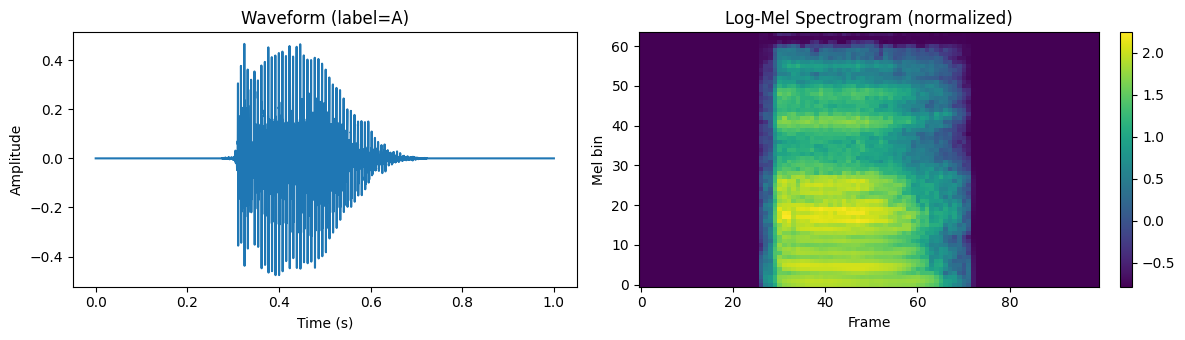

In [11]:
# Visualisasi & inspect data: waveform -> log-mel spectrogram (output MelSpectrogramLayer)
try:
    import matplotlib.pyplot as plt
except Exception as exc:
    raise RuntimeError(
        "Butuh matplotlib untuk visualisasi. Install dulu: pip install matplotlib"
    ) from exc

# Ambil 1 sample dari train_ds (waveform & label one-hot)
x_batch, y_batch = next(iter(train_ds.take(1)))
waveform = x_batch[0].numpy()  # (16000,) float32
label_idx = int(np.argmax(y_batch[0].numpy()))
label_name = CLASS_NAMES[label_idx]

# Ambil output layer mel yang ada di dalam model
mel_layer = model.get_layer("mel_spectrogram_layer")
log_mel = mel_layer(x_batch[:1], training=False).numpy()  # (1, time, mel, 1)
log_mel_2d = log_mel[0, :, :, 0]

print("Waveform:", waveform.shape, waveform.dtype, "min/max", float(waveform.min()), float(waveform.max()))
print("Label:", label_idx, label_name)
print("Log-mel spectrogram:", log_mel.shape, log_mel.dtype, "min/max", float(log_mel_2d.min()), float(log_mel_2d.max()))

# Plot
t = np.arange(waveform.shape[0]) / float(CONFIG.sample_rate)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(t, waveform)
axes[0].set_title(f"Waveform (label={label_name})")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

im = axes[1].imshow(log_mel_2d.T, aspect="auto", origin="lower")
axes[1].set_title("Log-Mel Spectrogram (normalized)")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Mel bin")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 8. Sanity check arsitektur

In [12]:
def sanity_check_model(model: tf.keras.Model):
    checks = []
    checks.append((isinstance(model, tf.keras.Model) and not isinstance(model, tf.keras.Sequential), "Keras Functional API model"))
    checks.append((tuple(model.input_shape[1:]) == (CONFIG.num_samples,), f"Raw audio input shape {model.input_shape}"))
    checks.append((model.layers[1].__class__.__name__ == "MelSpectrogramLayer", f"First layer after Input: {model.layers[1].__class__.__name__}"))
    checks.append((tuple(model.output_shape[1:]) == (CONFIG.num_classes,), f"Output shape {model.output_shape}"))

    forbidden = ["resnet", "vgg", "mobilenet", "efficientnet", "inception", "xception", "densenet"]
    layer_text = " ".join([layer.name.lower() + " " + layer.__class__.__name__.lower() for layer in model.layers])
    checks.append((not any(name in layer_text for name in forbidden), "No pretrained application models detected"))

    for passed, message in checks:
        print(("[PASS]" if passed else "[FAIL]"), message)
        if not passed:
            raise AssertionError(message)

sanity_check_model(model)

[PASS] Keras Functional API model
[PASS] Raw audio input shape (None, 16000)
[PASS] First layer after Input: MelSpectrogramLayer
[PASS] Output shape (None, 20)
[PASS] No pretrained application models detected


## 9. Custom loss + optimizer + metrics

In [13]:
def heartz_categorical_crossentropy(y_true, y_pred, label_smoothing: float = 0.1):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    if label_smoothing > 0:
        num_classes = tf.cast(tf.shape(y_true)[-1], tf.float32)
        y_true = y_true * (1.0 - label_smoothing) + (label_smoothing / num_classes)

    per_sample_loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    return tf.reduce_mean(per_sample_loss)

optimizer = tf.keras.optimizers.Adam(learning_rate=CONFIG.learning_rate)

## 10. Custom training loop dengan tf.GradientTape

Tidak ada `model.fit()` di cell ini.

In [14]:
train_writer = tf.summary.create_file_writer(str(LOG_DIR / "train"))
val_writer = tf.summary.create_file_writer(str(LOG_DIR / "val"))

@tf.function
def train_step(model, x_batch, y_batch):
    with tf.GradientTape() as tape:
        y_pred = model(x_batch, training=True)
        loss = heartz_categorical_crossentropy(
            y_batch,
            y_pred,
            label_smoothing=CONFIG.label_smoothing,
        )

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss, y_pred

@tf.function
def val_step(model, x_batch, y_batch):
    y_pred = model(x_batch, training=False)
    loss = heartz_categorical_crossentropy(
        y_batch,
        y_pred,
        label_smoothing=CONFIG.label_smoothing,
    )
    return loss, y_pred


def run_training(model, train_ds, val_ds=None):
    best_val_loss = float("inf")
    best_weights = None
    wait = 0
    history = []

    for epoch in range(1, CONFIG.epochs + 1):
        start = time.time()
        train_loss_metric = tf.keras.metrics.Mean()
        train_acc_metric = tf.keras.metrics.CategoricalAccuracy()

        for x_batch, y_batch in train_ds:
            loss, y_pred = train_step(model, x_batch, y_batch)
            train_loss_metric.update_state(loss)
            train_acc_metric.update_state(y_batch, y_pred)

        train_loss = float(train_loss_metric.result().numpy())
        train_acc = float(train_acc_metric.result().numpy())

        if val_ds is not None:
            val_loss_metric = tf.keras.metrics.Mean()
            val_acc_metric = tf.keras.metrics.CategoricalAccuracy()
            for x_batch, y_batch in val_ds:
                loss, y_pred = val_step(model, x_batch, y_batch)
                val_loss_metric.update_state(loss)
                val_acc_metric.update_state(y_batch, y_pred)
            val_loss = float(val_loss_metric.result().numpy())
            val_acc = float(val_acc_metric.result().numpy())
        else:
            val_loss = train_loss
            val_acc = train_acc

        with train_writer.as_default():
            tf.summary.scalar("loss", train_loss, step=epoch)
            tf.summary.scalar("accuracy", train_acc, step=epoch)
        with val_writer.as_default():
            tf.summary.scalar("loss", val_loss, step=epoch)
            tf.summary.scalar("accuracy", val_acc, step=epoch)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "seconds": time.time() - start,
        }
        history.append(row)

        print(
            f"Epoch {epoch:03d}/{CONFIG.epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
            f"{row['seconds']:.1f}s"
        )

        # Manual Early Stopping
        if val_loss < best_val_loss - CONFIG.min_delta:
            best_val_loss = val_loss
            best_weights = model.get_weights()
            wait = 0
            print("  -> best val_loss improved, weights cached")
        else:
            wait += 1
            print(f"  -> no improvement, wait={wait}/{CONFIG.early_stopping_patience}")
            if wait >= CONFIG.early_stopping_patience:
                print("Early stopping triggered.")
                break

    if best_weights is not None:
        model.set_weights(best_weights)
        print("Best weights restored.")

    return history

history = run_training(model, train_ds, val_ds)

Epoch 001/50 | train_loss=1.4846 train_acc=0.7025 | val_loss=4.6893 val_acc=0.0933 | 21.1s
  -> best val_loss improved, weights cached
Epoch 002/50 | train_loss=0.8419 train_acc=0.9604 | val_loss=0.7584 val_acc=0.9783 | 9.8s
  -> best val_loss improved, weights cached
Epoch 003/50 | train_loss=0.7564 train_acc=0.9862 | val_loss=0.6993 val_acc=0.9950 | 9.1s
  -> best val_loss improved, weights cached
Epoch 004/50 | train_loss=0.7232 train_acc=0.9938 | val_loss=0.6618 val_acc=0.9983 | 9.7s
  -> best val_loss improved, weights cached
Epoch 005/50 | train_loss=0.7075 train_acc=0.9959 | val_loss=0.6650 val_acc=1.0000 | 9.7s
  -> no improvement, wait=1/8
Epoch 006/50 | train_loss=0.6930 train_acc=0.9961 | val_loss=0.6700 val_acc=0.9983 | 21.0s
  -> no improvement, wait=2/8
Epoch 007/50 | train_loss=0.6835 train_acc=0.9977 | val_loss=0.6427 val_acc=0.9967 | 10.8s
  -> best val_loss improved, weights cached
Epoch 008/50 | train_loss=0.6830 train_acc=0.9975 | val_loss=0.6535 val_acc=0.9983 | 9.

## 11. Evaluasi test set

In [15]:
def evaluate_dataset(model, ds, split_name="test"):
    if ds is None:
        print(f"No {split_name} dataset available.")
        return None

    loss_metric = tf.keras.metrics.Mean()
    acc_metric = tf.keras.metrics.CategoricalAccuracy()

    y_true_all = []
    y_pred_all = []

    for x_batch, y_batch in ds:
        y_pred = model(x_batch, training=False)
        loss = heartz_categorical_crossentropy(y_batch, y_pred, label_smoothing=0.0)
        loss_metric.update_state(loss)
        acc_metric.update_state(y_batch, y_pred)
        y_true_all.extend(tf.argmax(y_batch, axis=1).numpy().tolist())
        y_pred_all.extend(tf.argmax(y_pred, axis=1).numpy().tolist())

    result = {
        f"{split_name}_loss": float(loss_metric.result().numpy()),
        f"{split_name}_accuracy": float(acc_metric.result().numpy()),
    }
    print(result)
    return result, y_true_all, y_pred_all

test_result = evaluate_dataset(model, test_ds, "test")

{'test_loss': 0.11592499911785126, 'test_accuracy': 1.0}


### 11.1 Evaluasi MAE + simpan metrics (jobdesk evidence)

In [ ]:
import json
from pathlib import Path

ACC_THRESHOLD = 0.85
MAE_THRESHOLD = 0.02

if test_result is None:
    print("No test_result available. Run the evaluation cell above first.")
else:
    test_metrics, _, _ = test_result
    test_acc = float(test_metrics.get("test_accuracy", float("nan")))
    test_loss = float(test_metrics.get("test_loss", float("nan")))

    mae_metric = tf.keras.metrics.Mean()
    for x_batch, y_batch in test_ds:
        probs = model(x_batch, training=False)
        batch_mae = tf.reduce_mean(tf.abs(y_batch - probs))
        mae_metric.update_state(batch_mae)
    test_mae = float(mae_metric.result().numpy())

    meets_acc = test_acc >= ACC_THRESHOLD
    meets_mae = test_mae <= MAE_THRESHOLD

    metrics_payload = {
        "test_loss": test_loss,
        "test_accuracy": test_acc,
        "test_mae": test_mae,
        "thresholds": {"accuracy": ACC_THRESHOLD, "mae": MAE_THRESHOLD},
        "meets": {"accuracy": meets_acc, "mae": meets_mae},
        "all_ok": bool(meets_acc and meets_mae),
    }

    out_path = Path("outputs/metrics_notebook.json")
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(metrics_payload, f, indent=2)

    print("Saved:", out_path.resolve())
    print(metrics_payload)

## 12. Export model dan metadata

In [16]:
# Simpan label dan config untuk dipakai FastAPI.
with open(CLASS_NAMES_PATH, "w", encoding="utf-8") as f:
    json.dump(CLASS_NAMES, f, indent=2)

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(asdict(CONFIG), f, indent=2)

# Keras native format, paling praktis untuk load di FastAPI.
model.save(KERAS_MODEL_PATH)
print("Saved Keras model to:", KERAS_MODEL_PATH.resolve())

# SavedModel export untuk kebutuhan produksi/deployment TensorFlow.
if SAVED_MODEL_DIR.exists():
    shutil.rmtree(SAVED_MODEL_DIR)

try:
    model.export(str(SAVED_MODEL_DIR))  # Keras 3
except Exception as exc:
    print("model.export failed, fallback to tf.saved_model.save:", repr(exc))
    tf.saved_model.save(model, str(SAVED_MODEL_DIR))

print("SavedModel directory:", SAVED_MODEL_DIR.resolve())
print("Class names:", CLASS_NAMES_PATH.resolve())
print("Config:", CONFIG_PATH.resolve())

Saved Keras model to: /content/Heartz/machine-learning/outputs/heartz_model.keras
Saved artifact at 'outputs/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 16000), dtype=tf.float32, name='raw_audio_waveform_16khz_1s')
Output Type:
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Captures:
  134944268722704: TensorSpec(shape=(257, 64), dtype=tf.float32, name=None)
  134944268721360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134944268723664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134944268722128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134944268722896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134944268723280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134944268719632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134944268720592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134944268723472: TensorSpec(shape=(), dtype=tf.resour

### 12.1 Verifikasi artifact export

In [ ]:
from pathlib import Path

def _stat(p: Path) -> str:
    if not p.exists():
        return "MISSING"
    if p.is_dir():
        return f"DIR ({sum(1 for _ in p.rglob('*'))} files)"
    return f"FILE ({p.stat().st_size / 1024:.1f} KB)"

artifacts = {
    "heartz_model.keras": Path(str(KERAS_MODEL_PATH)) if "KERAS_MODEL_PATH" in globals() else Path("outputs/heartz_model.keras"),
    "saved_model/": Path(str(SAVED_MODEL_DIR)) if "SAVED_MODEL_DIR" in globals() else Path("outputs/saved_model"),
    "class_names.json": Path(str(CLASS_NAMES_PATH)) if "CLASS_NAMES_PATH" in globals() else Path("outputs/class_names.json"),
    "heartz_config.json": Path(str(CONFIG_PATH)) if "CONFIG_PATH" in globals() else Path("outputs/heartz_config.json"),
    "logs/": Path("outputs/logs"),
    "metrics_notebook.json": Path("outputs/metrics_notebook.json"),
}

for name, path in artifacts.items():
    print(f"- {name}: {path.resolve()} -> {_stat(path)}")

## 13. Quick inference test dari satu file `.wav`

In [17]:
def load_one_wav_for_inference(path: str) -> tf.Tensor:
    audio_binary = tf.io.read_file(path)
    audio, sample_rate = tf.audio.decode_wav(audio_binary, desired_channels=1, desired_samples=CONFIG.num_samples)
    tf.debugging.assert_equal(sample_rate, CONFIG.sample_rate, message="Sample rate harus 16000 Hz")
    waveform = tf.squeeze(audio, axis=-1)
    return tf.expand_dims(waveform, axis=0)  # (1, 16000)

# Ganti path ini ke file test yang lu punya.
SAMPLE_WAV = test_paths[0] if test_paths else paths[0]
waveform = load_one_wav_for_inference(SAMPLE_WAV)
probs = model(waveform, training=False).numpy()[0]
pred_idx = int(np.argmax(probs))
confidence = float(probs[pred_idx])

print("File:", SAMPLE_WAV)
print("Prediction:", CLASS_NAMES[pred_idx])
print("Confidence:", confidence)

File: data/clean_wav/Pa/Pa_0364.wav
Prediction: Pa
Confidence: 0.9321999549865723


## 14. TensorBoard

Jalankan di terminal dari folder `machine-learning`:

```bash
tensorboard --logdir outputs/logs
```

Lalu buka `http://localhost:6006`.

## 15. Setelah notebook selesai

Kalau model sudah ke-export, kamu bisa demo dari terminal (jalankan dari repo root):

```powershell
# 1) Evaluasi + simpan outputs/metrics.json
cd machine-learning
python evaluate.py --max-samples 200 --output-json outputs/metrics.json

# 2) Inference CLI (contoh 1 file wav)
python infer.py --wav "data/clean_wav/A/some.wav" --topk 5

# 3) Jalankan API
python -m uvicorn api.main:app --reload

# 4) One-command full demo (evaluate -> start API -> predict -> stop)
cd ..
powershell -ExecutionPolicy Bypass -File machine-learning/demo_run.ps1
```

Catatan Windows: `curl` di PowerShell itu alias `Invoke-WebRequest`, jadi gunakan `curl.exe` kalau mau ngetes pakai curl.

In [ ]:
from __future__ import annotations

import shutil
from pathlib import Path

# Optional (Colab only): copy outputs to Google Drive for backup.
if 'is_colab' in globals() and is_colab():
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    dst = Path('/content/drive/MyDrive/Heartz-training-output/outputs')
    src = Path('outputs')
    if src.exists():
        dst.parent.mkdir(parents=True, exist_ok=True)
        if dst.exists():
            shutil.rmtree(dst)
        shutil.copytree(src, dst)
        print('Copied outputs to:', dst)
    else:
        print('[SKIP] outputs/ not found')
else:
    print('[SKIP] Google Drive backup only runs on Colab')

Mounted at /content/drive


In [ ]:
from __future__ import annotations

import subprocess
from typing import Iterable, Optional

def run_git(args: Iterable[str], *, check: bool = True, mask: bool = False, extra_env: Optional[dict] = None) -> subprocess.CompletedProcess[str]:
    cmd = ["git", *args]
    env = None
    if extra_env:
        env = {**dict(**__import__('os').environ), **extra_env}
    if mask:
        print("$ git", " ".join(args[:-1] + ["<masked>"]) if len(args) else "")
    else:
        print("$", " ".join(cmd))
    return subprocess.run(cmd, check=check, text=True, capture_output=False, env=env)

# Quick status (should work local + Colab if git exists)
try:
    run_git(["status"])
    run_git(["remote", "-v"], check=False)
except FileNotFoundError:
    print("[ERROR] `git` not found on PATH. Install Git or run these steps in a terminal.")

On branch ML-ghildan
Your branch is up to date with 'origin/ML-ghildan'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   outputs/class_names.json
	new file:   outputs/heartz_config.json
	new file:   outputs/heartz_model.keras
	new file:   outputs/logs/20260527-145617/train/events.out.tfevents.1779893793.423d9e6ca72e.2284.0.v2
	new file:   outputs/logs/20260527-145617/val/events.out.tfevents.1779893793.423d9e6ca72e.2284.1.v2
	new file:   outputs/saved_model/fingerprint.pb
	new file:   outputs/saved_model/saved_model.pb
	new file:   outputs/saved_model/variables/variables.data-00000-of-00001
	new file:   outputs/saved_model/variables/variables.index



In [ ]:
from __future__ import annotations

from pathlib import Path

# Stage minimal, jobdesk-relevant artifacts (skip missing).
to_add = [
    Path("notebooks/Heartz_Train.ipynb"),
    Path("outputs/class_names.json"),
    Path("outputs/heartz_config.json"),
    Path("outputs/metrics_notebook.json"),
    Path("outputs/heartz_model.keras"),
    Path("outputs/saved_model"),
    Path("outputs/logs"),
]

missing = [p for p in to_add if not p.exists()]
present = [p for p in to_add if p.exists()]

if missing:
    print("[INFO] Missing (will skip):")
    for p in missing:
        print("-", p.as_posix())

if not present:
    print("[WARN] Nothing to stage yet.")
else:
    # Use -f to add artifacts that might be gitignored (model/logs).
    try:
        for p in present:
            run_git(["add", "-f", p.as_posix()])
        run_git(["status"])
    except NameError:
        print("[ERROR] `run_git` not defined. Run the Git status cell above first.")

In [ ]:
from __future__ import annotations

# Optional: set git identity for THIS repo only (not global).
try:
    name = input("Git user.name (blank to skip): ").strip()
    email = input("Git user.email (blank to skip): ").strip()
    if name:
        run_git(["config", "user.name", name])
    if email:
        run_git(["config", "user.email", email])
    run_git(["config", "--get", "user.name"], check=False)
    run_git(["config", "--get", "user.email"], check=False)
except NameError:
    print("[ERROR] `run_git` not defined. Run the Git status cell above first.")

In [ ]:
from __future__ import annotations

import datetime
import subprocess

# Interactive commit
try:
    # Ensure there is something staged
    has_staged = subprocess.run(["git", "diff", "--cached", "--quiet"]).returncode != 0
    if not has_staged:
        print("[WARN] No staged changes. Run the staging cell first.")
    else:
        default_msg = f"Update Heartz artifacts ({datetime.date.today().isoformat()})"
        msg = input(f"Commit message (default: {default_msg}): ").strip() or default_msg
        confirm = input(f"Commit now? [y/N] ").strip().lower()
        if confirm == "y":
            run_git(["commit", "-m", msg])
        else:
            print("[SKIP] Commit cancelled")
except NameError:
    print("[ERROR] `run_git` not defined. Run the Git status cell above first.")
except FileNotFoundError:
    print("[ERROR] `git` not found on PATH.")

[ML-ghildan d725a314] Add trained Heartz model artifacts
 9 files changed, 42 insertions(+)
 create mode 100644 machine-learning/outputs/class_names.json
 create mode 100644 machine-learning/outputs/heartz_config.json
 create mode 100644 machine-learning/outputs/heartz_model.keras
 create mode 100644 machine-learning/outputs/logs/20260527-145617/train/events.out.tfevents.1779893793.423d9e6ca72e.2284.0.v2
 create mode 100644 machine-learning/outputs/logs/20260527-145617/val/events.out.tfevents.1779893793.423d9e6ca72e.2284.1.v2
 create mode 100644 machine-learning/outputs/saved_model/fingerprint.pb
 create mode 100644 machine-learning/outputs/saved_model/saved_model.pb
 create mode 100644 machine-learning/outputs/saved_model/variables/variables.data-00000-of-00001
 create mode 100644 machine-learning/outputs/saved_model/variables/variables.index


In [ ]:
from __future__ import annotations

import base64
from getpass import getpass

# Interactive push (optional token for HTTPS)
try:
    do_push = input("Push to remote? [y/N] ").strip().lower()
    if do_push != "y":
        print("[SKIP] Push")
    else:
        # Detect current branch
        proc = subprocess.run(["git", "rev-parse", "--abbrev-ref", "HEAD"], text=True, capture_output=True, check=True)
        current_branch = proc.stdout.strip()
        branch = input(f"Branch to push (default: {current_branch}): ").strip() or current_branch
        remote = input("Remote name (default: origin): ").strip() or "origin"
        # Read remote URL
        proc = subprocess.run(["git", "remote", "get-url", remote], text=True, capture_output=True, check=True)
        remote_url = proc.stdout.strip()
        print("Remote URL:", remote_url)

        if remote_url.startswith("https://") and "github.com" in remote_url:
            use_token = input("Use token for HTTPS auth? (recommended only if needed) [y/N] ").strip().lower()
            if use_token == "y":
                token = getpass("GitHub token (input hidden): ")
                # WARNING: token will be present (base64) in process args briefly.
                basic = base64.b64encode(("x-access-token:" + token).encode("utf-8")).decode("ascii")
                header = f"AUTHORIZATION: basic {basic}"
                run_git(["-c", f"http.extraheader={header}", "push", remote, branch], mask=True)
            else:
                # Let Git / credential manager handle auth
                run_git(["push", remote, branch])
        else:
            # SSH or other remotes: no token handling here
            run_git(["push", remote, branch])
except NameError:
    print("[ERROR] `run_git` not defined. Run the Git status cell above first.")
except subprocess.CalledProcessError as exc:
    print("[ERROR] Push failed:", exc)
    print("If this is an auth issue on Windows, try running `git push` in a terminal once so Credential Manager can store creds.")

Masukkan GitHub Personal Access Token: ··········
Enumerating objects: 22, done.
Counting objects: 100% (22/22), done.
Delta compression using up to 2 threads
Compressing objects: 100% (18/18), done.
Writing objects: 100% (19/19), 1.95 MiB | 2.48 MiB/s, done.
Total 19 (delta 3), reused 2 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 2 local objects.
To https://github.com/ghildnsy/Heartz.git
   77530d87..d725a314  ML-ghildan -> ML-ghildan


In [ ]:
# Post-push verification (optional)
try:
    run_git(["status"], check=False)
    run_git(["remote", "-v"], check=False)
except NameError:
    print("[ERROR] `run_git` not defined. Run the Git status cell above first.")

origin	https://github.com/ghildnsy/Heartz.git (fetch)
origin	https://github.com/ghildnsy/Heartz.git (push)
